# Sensitivity analysis

Which parameters drive each RAW case's net impact? The parameters on the sheet are grouped into four types:

- **design** choices: product size formula constants (density, ratios), bill of materials (recycled/co-product share),
- **manufacturing** choices: machine weight, power, output rate, machine lifetime, process yield, machine source,
- **circularity** choices: lifetime, repair, end-of-life shares,
- **location** choices: electricity country of each step and of the end-of-life grid (varies between `location_choices` on the sheet).

Method: variance-based total-order Sobol' indices (Jansen estimator, `raw_lca/sensitivity.py`) with bootstrap 95 % confidence intervals, per group and per parameter, for the net impact in each charted category; parameter ranges are the min/max on the sheet. The one-at-a-time tornado shows the swing of the net climate change between min and max of each parameter. Background (ecoinvent) uncertainty is not part of this analysis. Sample size N: `sobol_base_samples` on the sheet.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))          # repo root, so that `raw_lca` can be imported
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from raw_lca import Background, Model, load_inputs, run_products, spec_variable
from raw_lca.paths import BACKGROUND, RESULTS, newest_snapshot
from raw_lca.plots import plot_today_vs_2050

SNAPSHOT = newest_snapshot()
inp = load_inputs(SNAPSHOT)                          # validates the sheet snapshot, stops on errors
print("sheet snapshot:", SNAPSHOT.name)

# the two backgrounds shown in the charts: the scenarios flagged in_results on the sheet (first = today)
scn = inp.scenarios[inp.scenarios["in_results"].astype(str).str.upper() == "TRUE"]
(id_a, label_a), (id_b, label_b) = list(zip(scn["scenario_id"], scn["label"]))[:2]
models = {id_a: Model(inp, Background(BACKGROUND, id_a)), id_b: Model(inp, Background(BACKGROUND, id_b))}
(RESULTS / "figures").mkdir(parents=True, exist_ok=True); (RESULTS / "tables").mkdir(parents=True, exist_ok=True)

from raw_lca.sensitivity import sobol, tornado
from raw_lca.plots import plot_group_sensitivity, plot_parameter_sensitivity, plot_tornado, chart_categories
N, seed = int(inp.setup["sobol_base_samples"]), int(inp.setup["mc_seed"])

NOTICE: no sheet snapshot with the redesigned tabs yet - using /Users/tsuitpy/Library/CloudStorage/OneDrive-UniversiteitLeiden/01_Projects/RAW/biobased_construction_impact_calculator/data/sheet_templates
sheet snapshot: sheet_templates


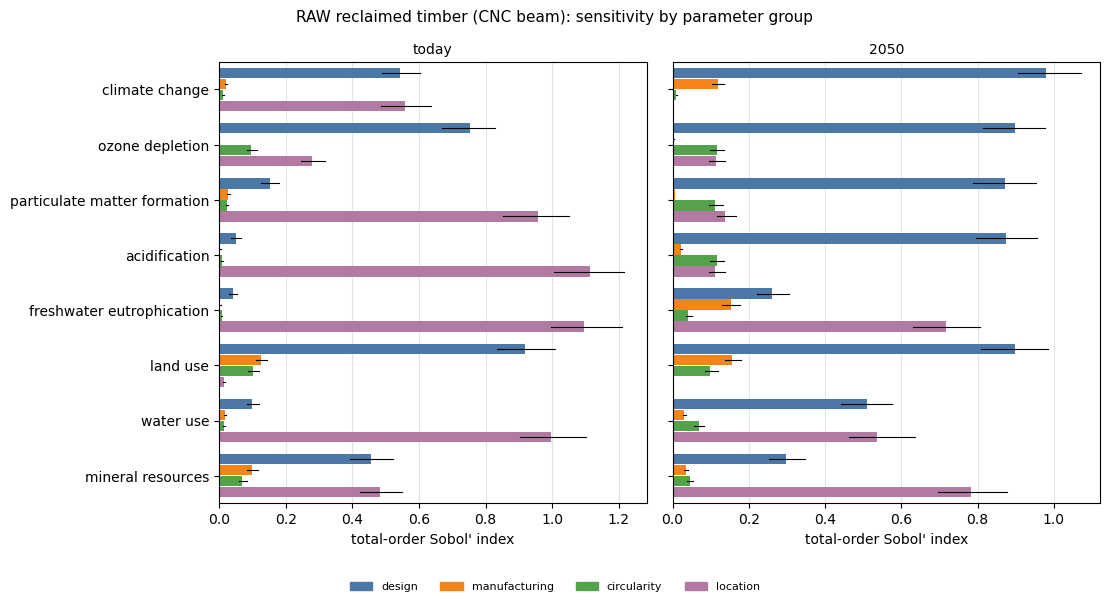

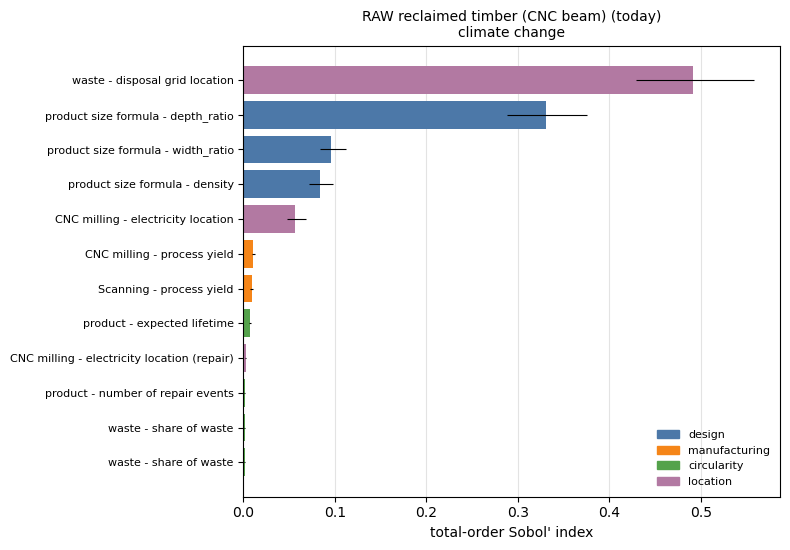

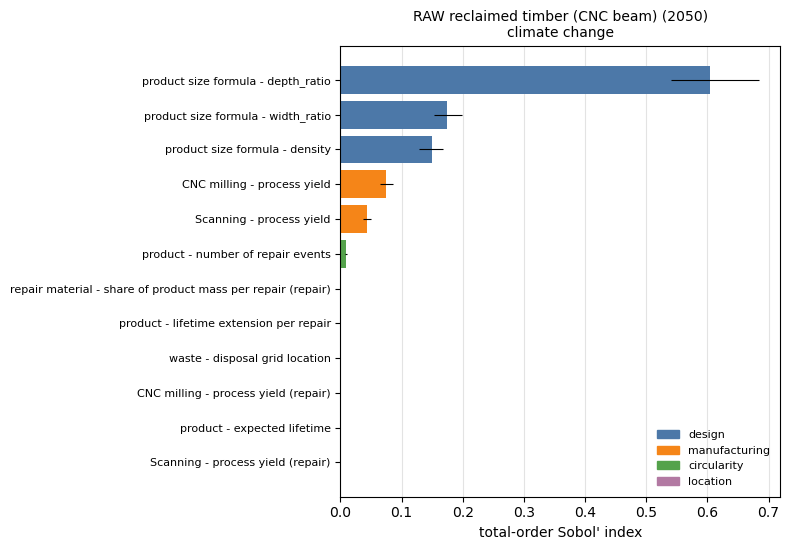

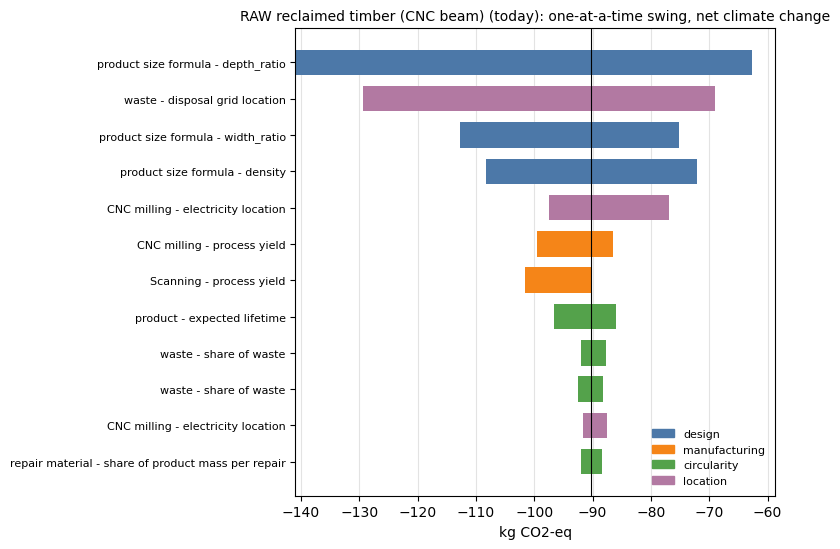

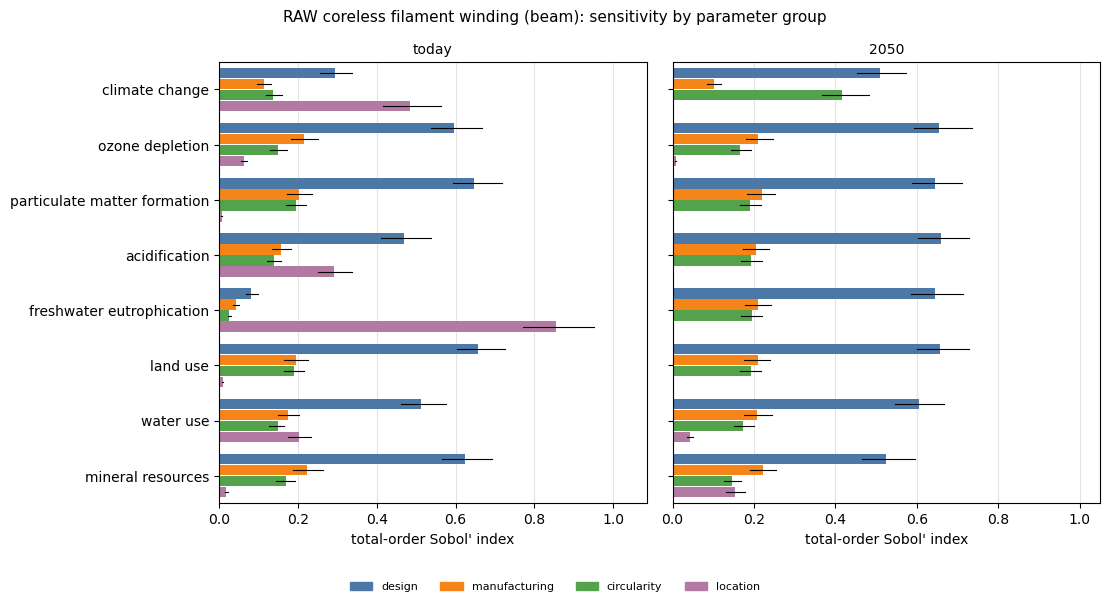

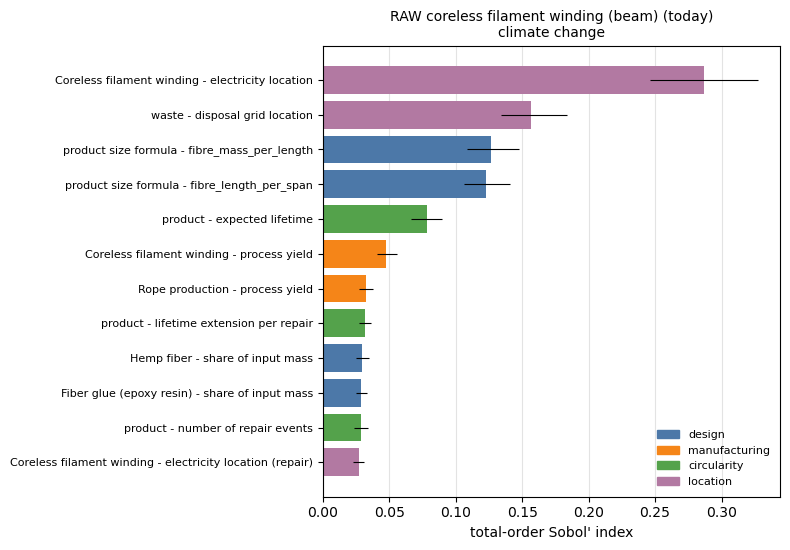

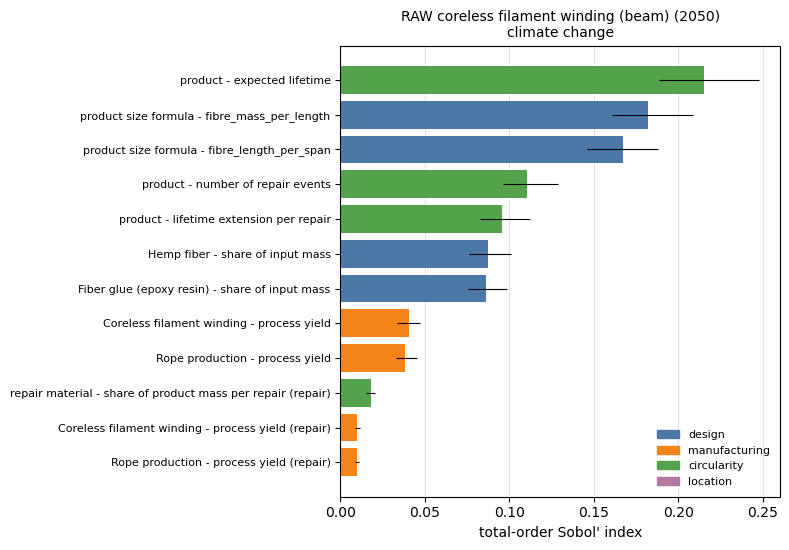

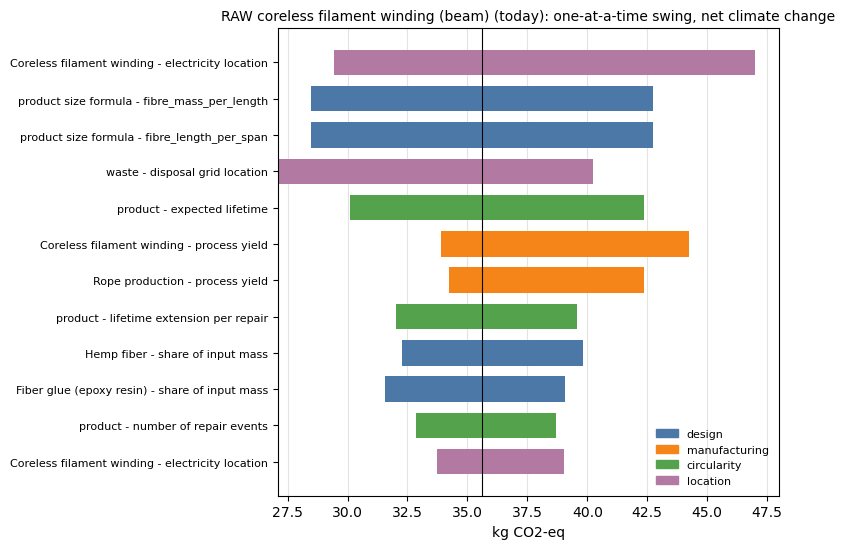

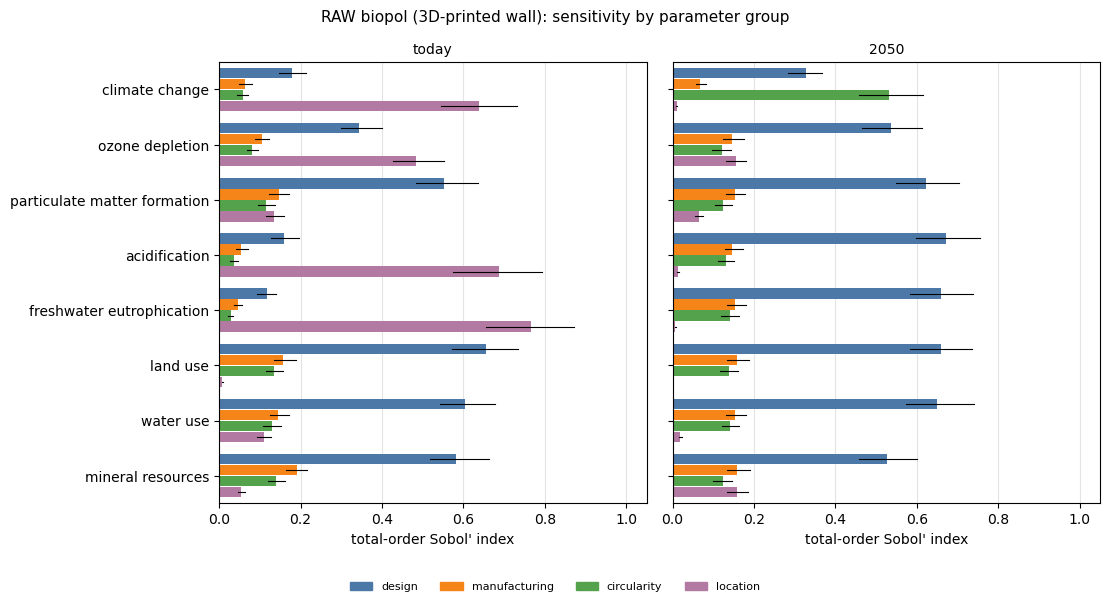

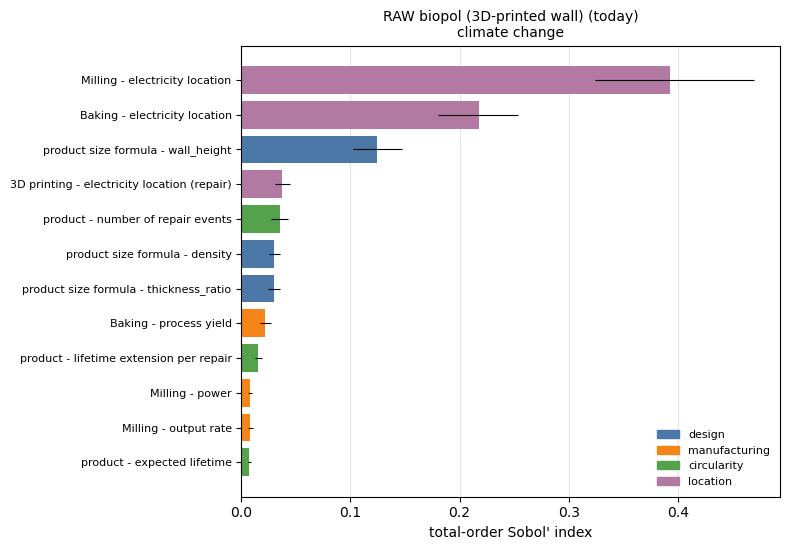

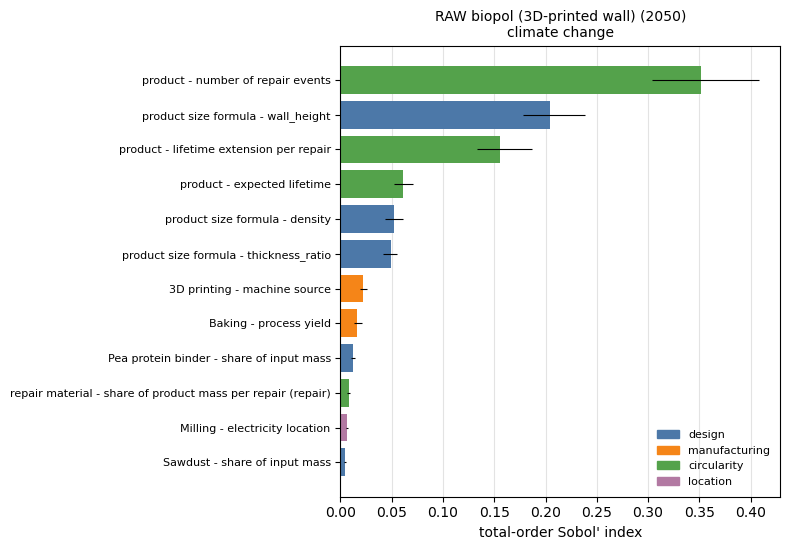

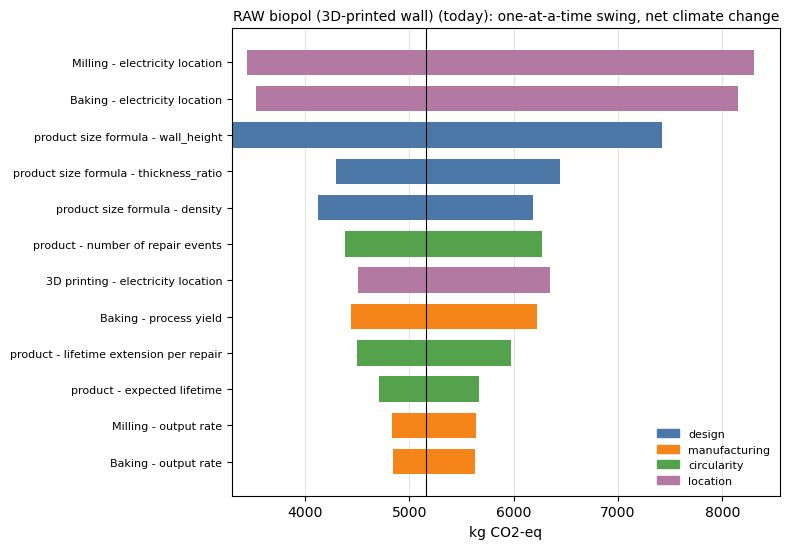

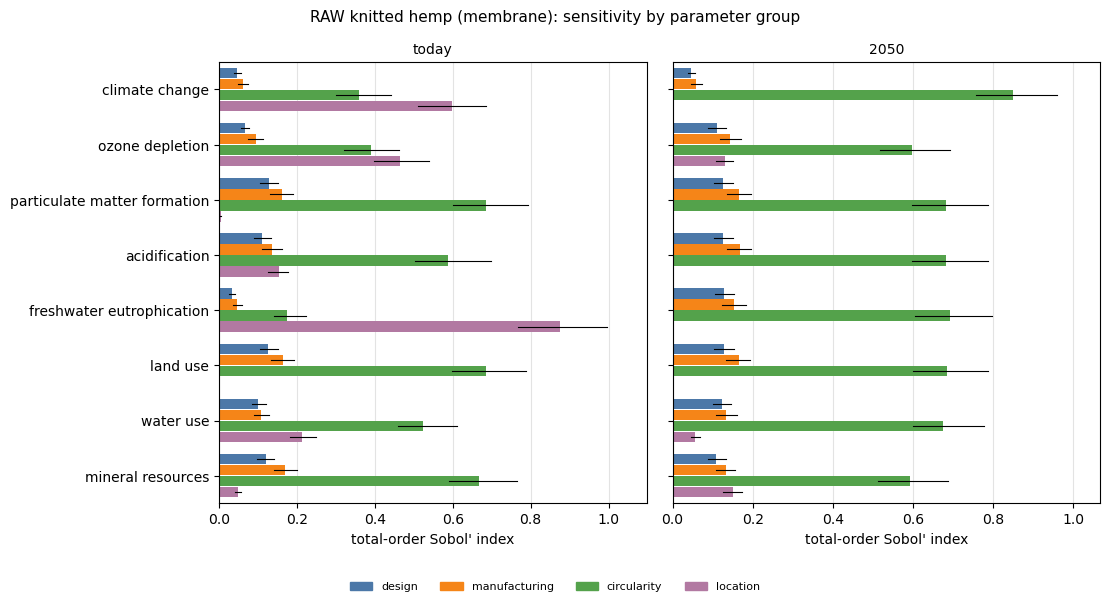

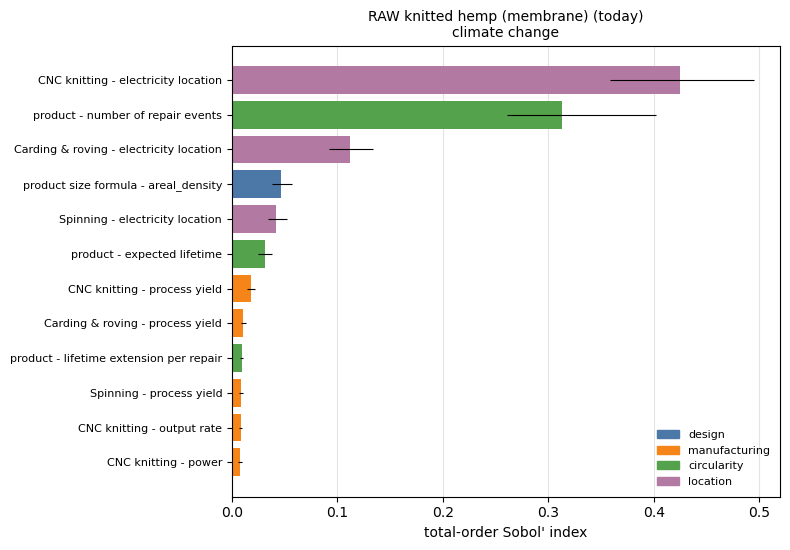

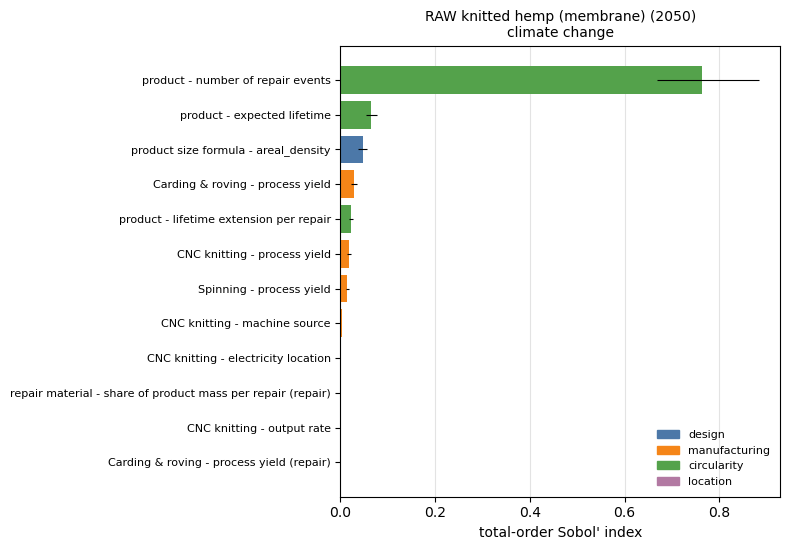

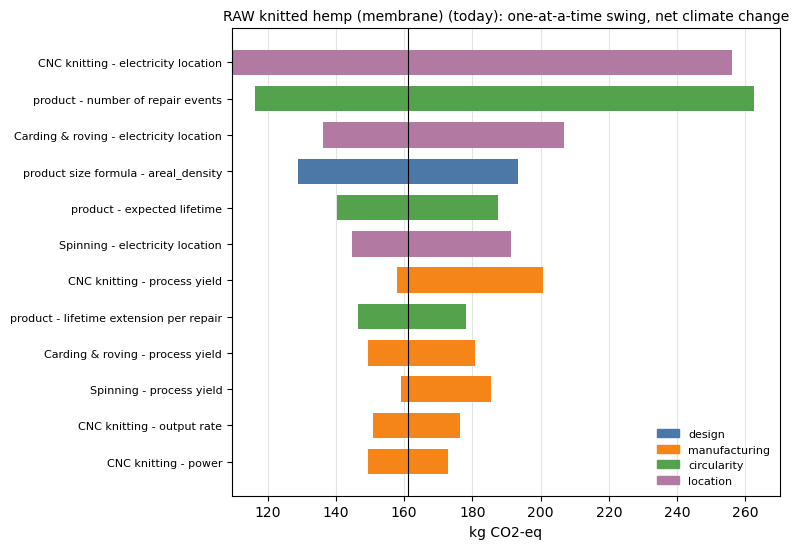

In [2]:
for case_id, display_name in inp.raw_cases().items():
    by_group, by_param = {}, {}
    for sid, lab in ((id_a, label_a), (id_b, label_b)):
        by_group[lab] = sobol(models[sid], case_id, N, seed, by="group")
        by_param[lab] = sobol(models[sid], case_id, N, seed, by="parameter")
        by_group[lab].assign(raw_case=case_id, background=lab).to_csv(RESULTS / "tables" / f"sobol_group_{case_id}_{sid}.csv", index=False)
        by_param[lab].assign(raw_case=case_id, background=lab).to_csv(RESULTS / "tables" / f"sobol_parameter_{case_id}_{sid}.csv", index=False)
    fig = plot_group_sensitivity(inp, f"{display_name}: sensitivity by parameter group", by_group)
    fig.savefig(RESULTS / "figures" / f"sensitivity_groups_{case_id}.png", dpi=150); fig.savefig(RESULTS / "figures" / f"sensitivity_groups_{case_id}.pdf")
    plt.show()
    for lab in (label_a, label_b):
        fig = plot_parameter_sensitivity(f"{display_name} ({lab})", by_param[lab], "climate change")
        fig.savefig(RESULTS / "figures" / f"sensitivity_parameters_{case_id}_{lab.replace(' ', '')}.png", dpi=150)
        plt.show()
    tor = tornado(models[id_a], case_id, "climate change")
    tor.to_csv(RESULTS / "tables" / f"tornado_{case_id}.csv", index=False)
    fig = plot_tornado(f"{display_name} ({label_a}): one-at-a-time swing, net climate change", tor, "kg CO2-eq")
    fig.savefig(RESULTS / "figures" / f"tornado_{case_id}.png", dpi=150)
    plt.show()